# Lab 7 - Predictive Analysis (Classification)

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
%matplotlib inline
plt.rcParams['figure.dpi'] = 70

In [2]:
Y = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')['Class'].to_numpy()
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
X = preprocessing.StandardScaler().fit(X).transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print('test samples:', X_test.shape[0])

test samples: 18


### Logistic Regression

In [3]:
lr = GridSearchCV(LogisticRegression(max_iter=1000), {'C':[0.01,0.1,1],'penalty':['l2'],'solver':['lbfgs']}, cv=10).fit(X_train, Y_train)
print('val acc:', round(lr.best_score_,4), '| test acc:', round(lr.score(X_test, Y_test),4))

val acc: 0.8464 | test acc: 0.8333


C:\Users\Minh Moon\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Minh Moon\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Minh 

### Support Vector Machine

In [4]:
svm = GridSearchCV(SVC(), {'kernel':('linear','rbf','poly','sigmoid'),'C':np.logspace(-3,3,5),'gamma':np.logspace(-3,3,5)}, cv=10).fit(X_train, Y_train)
print('best kernel:', svm.best_params_['kernel'], '| val acc:', round(svm.best_score_,4), '| test acc:', round(svm.score(X_test, Y_test),4))

best kernel: sigmoid | val acc: 0.8482 | test acc: 0.8333


### Decision Tree

In [5]:
tree = GridSearchCV(DecisionTreeClassifier(random_state=0), {'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':[2*n for n in range(1,10)],'max_features':['sqrt'],'min_samples_leaf':[1,2,4],'min_samples_split':[2,5,10]}, cv=10).fit(X_train, Y_train)
print('val acc:', round(tree.best_score_,4), '| test acc:', round(tree.score(X_test, Y_test),4))

val acc: 0.8625 | test acc: 0.8333


### K-Nearest Neighbors

In [6]:
knn = GridSearchCV(KNeighborsClassifier(), {'n_neighbors':list(range(1,11)),'algorithm':['auto','ball_tree','kd_tree','brute'],'p':[1,2]}, cv=10).fit(X_train, Y_train)
print('val acc:', round(knn.best_score_,4), '| test acc:', round(knn.score(X_test, Y_test),4))

val acc: 0.8482 | test acc: 0.8333


### Model comparison

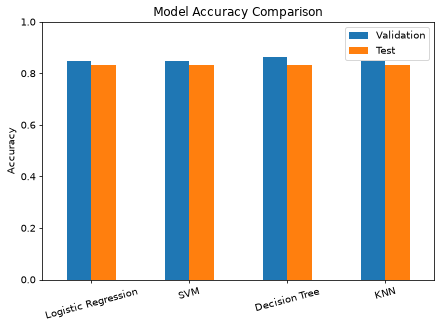

,Validation,Test
Logistic Regression,0.846429,0.833333
SVM,0.848214,0.833333
Decision Tree,0.862500,0.833333
KNN,0.848214,0.833333


In [7]:
scores = {'Logistic Regression':lr, 'SVM':svm, 'Decision Tree':tree, 'KNN':knn}
comp = pd.DataFrame({'Validation':{k:v.best_score_ for k,v in scores.items()}, 'Test':{k:v.score(X_test,Y_test) for k,v in scores.items()}})
comp.plot(kind='bar'); plt.ylabel('Accuracy'); plt.ylim(0,1); plt.title('Model Accuracy Comparison'); plt.xticks(rotation=15); plt.tight_layout(); plt.show()
comp

### Confusion matrix of the best model (Decision Tree)

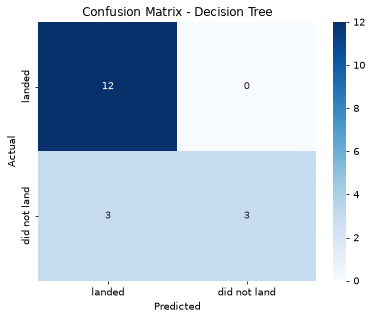

Best model: Decision Tree | test accuracy: 0.8333


In [8]:
best = tree
yhat = best.predict(X_test)
cm = confusion_matrix(Y_test, yhat, labels=[1,0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['landed','did not land'], yticklabels=['landed','did not land'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix - Decision Tree'); plt.show()
print('Best model: Decision Tree | test accuracy:', round(best.score(X_test, Y_test),4))